# Breast Cancer Subtype Prediction
# Step 2: Preprocessing & Data Splitting
# Correct Methodology: Split -> Impute -> Normalize

## Import Libraries

In [10]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

## Define Load & Save Functions

In [11]:
io_dir = '../outputs'

def load_object(filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'rb') as f:
        return pickle.load(f)

def save_object(obj, filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    print(f"💾 Saved: {file_path}")

print("✅ IO Functions Defined.")

✅ IO Functions Defined.


## Load Raw Data (From Step 1)

In [12]:
print("Loading raw datasets from '../outputs/'...")

try:
    X_rna = load_object('X_rna_raw')
    X_meth = load_object('X_meth_raw')
    y = load_object('y_labels')
    print("✅ Data Loaded Successfully.")
    print(f"RNA Shape: {X_rna.shape}")
    print(f"Methylation Shape: {X_meth.shape}")
    print(f"Labels Shape: {y.shape}")
except FileNotFoundError:
    print("❌ Error: Raw files not found. Please run 'Reading.ipynb' first.")

Loading raw datasets from '../outputs/'...
✅ Data Loaded Successfully.
RNA Shape: (549, 20155)
Methylation Shape: (549, 20106)
Labels Shape: (549,)


## Train/Test Split (CRITICAL STEP)


In [13]:
print("Splitting data into Train (80%) and Test (20%)...")


X_train_rna, X_test_rna, X_train_meth, X_test_meth, y_train, y_test = train_test_split(
    X_rna, 
    X_meth, 
    y, 
    test_size=0.2, 
    stratify=y,    
    random_state=42  
)

print(f"Train Set: {X_train_rna.shape[0]} samples")
print(f"Test Set:  {X_test_rna.shape[0]} samples")

Splitting data into Train (80%) and Test (20%)...
Train Set: 439 samples
Test Set:  110 samples


## Processing RNA-Seq Data


In [14]:
print("Processing RNA Data...")

rna_imputer = SimpleImputer(strategy='mean')
X_train_rna_imp = rna_imputer.fit_transform(X_train_rna)
X_test_rna_imp = rna_imputer.transform(X_test_rna)

X_train_rna_log = np.log2(X_train_rna_imp + 1)
X_test_rna_log = np.log2(X_test_rna_imp + 1)

rna_scaler = MinMaxScaler()
X_train_rna_norm = rna_scaler.fit_transform(X_train_rna_log)
X_test_rna_norm = rna_scaler.transform(X_test_rna_log)

print("✅ RNA Data Processed.")

Processing RNA Data...
✅ RNA Data Processed.


## Processing Methylation Data


In [15]:
print("Processing Methylation Data...")

meth_imputer = SimpleImputer(strategy='mean')
X_train_meth_imp = meth_imputer.fit_transform(X_train_meth)
X_test_meth_imp = meth_imputer.transform(X_test_meth)


meth_scaler = MinMaxScaler()
X_train_meth_norm = meth_scaler.fit_transform(X_train_meth_imp)
X_test_meth_norm = meth_scaler.transform(X_test_meth_imp)

print("✅ Methylation Data Processed.")

Processing Methylation Data...
✅ Methylation Data Processed.


## Visualization (PCA Check)


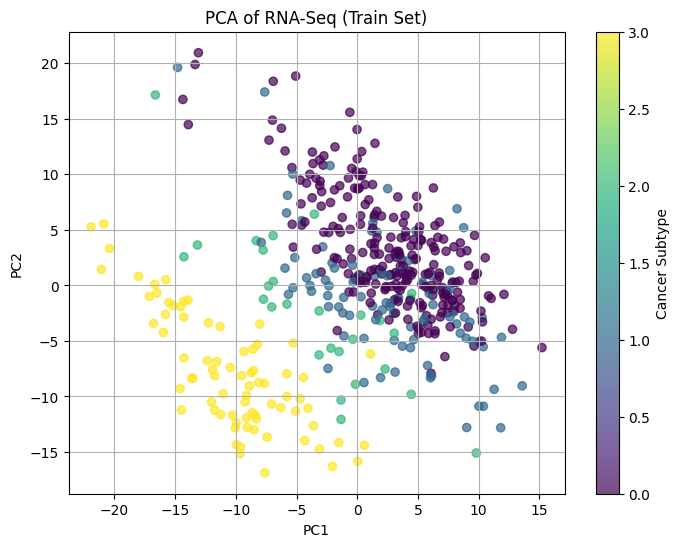

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_rna_norm)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.title('PCA of RNA-Seq (Train Set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cancer Subtype')
plt.grid(True)
plt.show()

## Saving Processed Data

In [17]:
print("Saving all processed files to '../outputs/'...")

save_object(X_train_rna_norm, 'X_train_rna')
save_object(X_test_rna_norm,  'X_test_rna')

save_object(X_train_meth_norm, 'X_train_meth')
save_object(X_test_meth_norm,  'X_test_meth')

save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print("\n🎉 Preprocessing Completed Successfully.")

Saving all processed files to '../outputs/'...
💾 Saved: ../outputs\X_train_rna.pkl
💾 Saved: ../outputs\X_test_rna.pkl
💾 Saved: ../outputs\X_train_meth.pkl
💾 Saved: ../outputs\X_test_meth.pkl
💾 Saved: ../outputs\y_train.pkl
💾 Saved: ../outputs\y_test.pkl

🎉 Preprocessing Completed Successfully.
